## Paso 1: cargar dataset y filtrar solo los 3 topics principales

In [ ]:
!python -m spacy download es_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 65.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import spacy
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
import nltk
from nltk.stem.snowball import SnowballStemmer

In [ ]:
RANDOM_STATE = 42

dataset = load_dataset("mariagrandury/fake_news_corpus_spanish")

df = dataset["test"].to_pandas()

print(df.shape)
display(df.head())

display(df["TOPICS"].value_counts())
display(df["CATEGORY"].value_counts())

topics_seleccionados = ["Covid-19", "Sociedad", "Política"]

df_model = df[df["TOPICS"].isin(topics_seleccionados)].copy()
df_model.reset_index(drop=True, inplace=True)

print(df_model.shape)

display(df_model["TOPICS"].value_counts())
display(df_model["CATEGORY"].value_counts())
display(pd.crosstab(df_model["TOPICS"], df_model["CATEGORY"]))

(572, 7)


,ID,CATEGORY,TOPICS,SOURCE,HEADLINE,TEXT,LINK
0,1,True,Covid-19,El Economista,Covid-19: mentiras que matan,El control de la Covid-19 no es sólo un tema d...,https://www.eleconomista.com.mx/opinion/Covid-...
1,2,False,Política,El matinal,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,https://www.elmatinal.com/espana-ultima-hora/e...
2,3,True,Política,El País,La comunidad musulmana catalana denuncia a Vox...,Las tres federaciones que agrupan al 90% de la...,https://elpais.com/espana/elecciones-catalanas...
3,4,False,Política,AFPFactual,None,Se han dado a conocer los datos electorales pr...,https://perma.cc/GYE6-SPMB
4,5,True,Sociedad,La Republica,El censo poblacional 2018 tendrá un costo de $...,La primera fase del censo será virtual y solo ...,https://www.larepublica.co/economia/el-censo-p...


,count
TOPICS,
Covid-19,237
Sociedad,195
Política,107
Internacional,14
Ciencia,13
Ambiental,4
Deporte,2


,count
CATEGORY,
True,286
False,286


(539, 7)


,count
TOPICS,
Covid-19,237
Sociedad,195
Política,107


,count
CATEGORY,
True,270
False,269


CATEGORY,False,True
TOPICS,,
Covid-19,119,118
Política,54,53
Sociedad,96,99


##Paso 2: preparar variables para modelado.

In [ ]:
df_modeling = df_model.copy()

df_modeling = df_modeling[["CATEGORY", "TOPICS", "TEXT"]].copy()

df_modeling["TEXT"] = (
    df_modeling["TEXT"]
    .astype(str)
    .str.replace(r"[\n\t\r]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_modeling["y"] = (~df_modeling["CATEGORY"]).astype(int)

X_text = df_modeling["TEXT"]
y = df_modeling["y"]

print(df_modeling.shape)
display(df_modeling.head())

print("Distribución de y:")
display(df_modeling["y"].value_counts())

print("Interpretación:")
print("1 = noticia falsa")
print("0 = noticia verdadera")

(539, 4)


,CATEGORY,TOPICS,TEXT,y
0,True,Covid-19,El control de la Covid-19 no es sólo un tema d...,0
1,False,Política,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,1
2,True,Política,Las tres federaciones que agrupan al 90% de la...,0
3,False,Política,Se han dado a conocer los datos electorales pr...,1
4,True,Sociedad,La primera fase del censo será virtual y solo ...,0


Distribución de y:


,count
y,
0,270
1,269


Interpretación:
1 = noticia falsa
0 = noticia verdadera


##Paso 3: separación train/test con estratificación

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Tamaño X_train:", X_train_text.shape)
print("Tamaño X_test:", X_test_text.shape)

print("\nDistribución y_train:")
display(y_train.value_counts())

print("\nDistribución y_test:")
display(y_test.value_counts())

print("\nPorcentaje y_train:")
display((y_train.value_counts(normalize=True) * 100).round(2))

print("\nPorcentaje y_test:")
display((y_test.value_counts(normalize=True) * 100).round(2))

Tamaño X_train: (431,)
Tamaño X_test: (108,)

Distribución y_train:


,count
y,
0,216
1,215



Distribución y_test:


,count
y,
0,54
1,54



Porcentaje y_train:


,proportion
y,
0,50.12
1,49.88



Porcentaje y_test:


,proportion
y,
0,50.0
1,50.0


##Paso 4: crear el pipeline TF-IDF + Random Forest.

In [ ]:
nlp = spacy.load("es_core_news_sm")
stopwords_es = list(nlp.Defaults.stop_words)

modelo_rf_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words=stopwords_es,
        lowercase=True,
        max_features=40000,
        ngram_range=(1, 2),
        token_pattern=r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]{3,}\b"
    )),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_features=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

modelo_rf_tfidf

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=40000, ngram_range=(1, 2),
                                 stop_words=['dice', 'cuándo', 'podrá', 'otra',
                                             'suyos', 'aquella', 'habrá',
                                             'podemos', 'esa', 'cualquier',
                                             'encima', 'ello', 'voy',
                                             'enseguida', 'siguiente', 'sea',
                                             'igual', 'verdadero', 'nos',
                                             'suyo', 'dos', 'proximo', 'sólo',
                                             'dónde', 'serán', 'medio', 'somos',
                                             'hemos', 'quizas', 'repente', ...],
                                 token_pattern='(?u)\\b[a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]{3,}\\b')),
                ('rf',
                 RandomForestClassifier(max_features=50, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

## Paso 5: Entrenamiento del modelo

In [ ]:
modelo_rf_tfidf.fit(X_train_text, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## Paso 6: Evaluación inicial del modelo con umbral 0.50

In [ ]:
y_pred = modelo_rf_tfidf.predict(X_test_text)

accuracy = accuracy_score(y_test, y_pred)
precision_fake = precision_score(y_test, y_pred, pos_label=1)
recall_fake = recall_score(y_test, y_pred, pos_label=1)
f1_fake = f1_score(y_test, y_pred, pos_label=1)

metricas_modelo = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision clase falsa", "Recall clase falsa", "F1-score clase falsa"],
    "Valor": [accuracy, precision_fake, recall_fake, f1_fake]
})

metricas_modelo["Valor"] = metricas_modelo["Valor"].round(4)

display(metricas_modelo)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Verdadera", "Falsa"]
))

matriz_confusion = confusion_matrix(y_test, y_pred)

display(pd.DataFrame(
    matriz_confusion,
    index=["Real verdadera", "Real falsa"],
    columns=["Predicha verdadera", "Predicha falsa"]
))

,Métrica,Valor
0,Accuracy,0.6852
1,Precision clase falsa,0.6282
2,Recall clase falsa,0.9074
3,F1-score clase falsa,0.7424


              precision    recall  f1-score   support

   Verdadera       0.83      0.46      0.60        54
       Falsa       0.63      0.91      0.74        54

    accuracy                           0.69       108
   macro avg       0.73      0.69      0.67       108
weighted avg       0.73      0.69      0.67       108



,Predicha verdadera,Predicha falsa
Real verdadera,25,29
Real falsa,5,49


## Paso 7: Ajuste experimental de umbral de decisión

In [ ]:
X_train_final_text, X_val_text, y_train_final, y_val = train_test_split(
    X_train_text,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

modelo_validacion = clone(modelo_rf_tfidf)

modelo_validacion.fit(X_train_final_text, y_train_final)

y_val_proba_fake = modelo_validacion.predict_proba(X_val_text)[:, 1]

umbrales = np.arange(0.30, 0.91, 0.05)

resultados_validacion = []

for umbral in umbrales:
    y_val_pred_umbral = (y_val_proba_fake >= umbral).astype(int)

    resultados_validacion.append({
        "umbral": round(umbral, 2),
        "accuracy": round(accuracy_score(y_val, y_val_pred_umbral), 4),
        "precision_fake": round(precision_score(y_val, y_val_pred_umbral, pos_label=1, zero_division=0), 4),
        "recall_fake": round(recall_score(y_val, y_val_pred_umbral, pos_label=1, zero_division=0), 4),
        "f1_fake": round(f1_score(y_val, y_val_pred_umbral, pos_label=1, zero_division=0), 4)
    })

df_umbrales_validacion = pd.DataFrame(resultados_validacion)

display(df_umbrales_validacion)

df_candidatos = df_umbrales_validacion[df_umbrales_validacion["recall_fake"] >= 0.70].copy()

mejor_umbral = df_candidatos.sort_values(
    by=["precision_fake", "f1_fake", "accuracy"],
    ascending=False
).iloc[0]["umbral"]

print("Mejor umbral seleccionado:", mejor_umbral)

,umbral,accuracy,precision_fake,recall_fake,f1_fake
0,0.30,0.5057,0.5000,1.0000,0.6667
1,0.35,0.5287,0.5119,1.0000,0.6772
2,0.40,0.5287,0.5119,1.0000,0.6772
3,0.45,0.5402,0.5181,1.0000,0.6825
4,0.50,0.5747,0.5385,0.9767,0.6942
5,0.55,0.5287,0.5167,0.7209,0.6019
6,0.60,0.6207,0.6190,0.6047,0.6118
7,0.65,0.6207,0.6562,0.4884,0.5600
8,0.70,0.6782,0.8261,0.4419,0.5758
9,0.75,0.5977,0.9000,0.2093,0.3396


Mejor umbral seleccionado: 0.5


## Paso 8: evaluación final con umbral 0.70

In [ ]:
mejor_umbral = 0.70

y_test_proba_fake = modelo_rf_tfidf.predict_proba(X_test_text)[:, 1]
y_pred_final = (y_test_proba_fake >= mejor_umbral).astype(int)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_fake_final = precision_score(y_test, y_pred_final, pos_label=1, zero_division=0)
recall_fake_final = recall_score(y_test, y_pred_final, pos_label=1, zero_division=0)
f1_fake_final = f1_score(y_test, y_pred_final, pos_label=1, zero_division=0)

metricas_finales = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision clase falsa", "Recall clase falsa", "F1-score clase falsa"],
    "Valor": [accuracy_final, precision_fake_final, recall_fake_final, f1_fake_final]
})

metricas_finales["Valor"] = metricas_finales["Valor"].round(4)

display(metricas_finales)

print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Verdadera", "Falsa"],
    zero_division=0
))

matriz_confusion_final = confusion_matrix(y_test, y_pred_final)

display(pd.DataFrame(
    matriz_confusion_final,
    index=["Real verdadera", "Real falsa"],
    columns=["Predicha verdadera", "Predicha falsa"]
))

,Métrica,Valor
0,Accuracy,0.6481
1,Precision clase falsa,0.8333
2,Recall clase falsa,0.3704
3,F1-score clase falsa,0.5128


              precision    recall  f1-score   support

   Verdadera       0.60      0.93      0.72        54
       Falsa       0.83      0.37      0.51        54

    accuracy                           0.65       108
   macro avg       0.71      0.65      0.62       108
weighted avg       0.71      0.65      0.62       108



,Predicha verdadera,Predicha falsa
Real verdadera,50,4
Real falsa,34,20


## Paso 9: visualizar la matriz de confusión final.

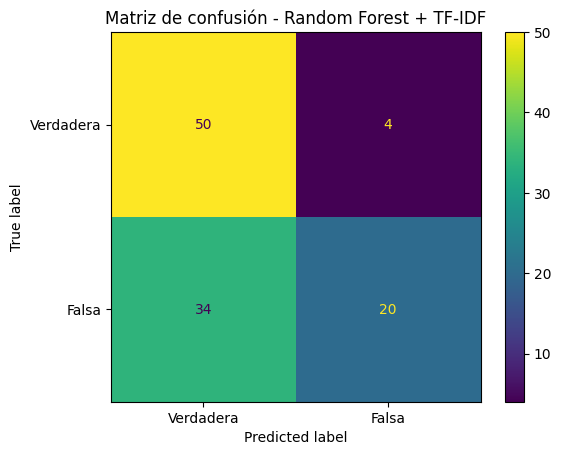

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_final,
    display_labels=["Verdadera", "Falsa"]
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - Random Forest + TF-IDF")
plt.show()

##Paso 10: Curva ROC y AUC

AUC ROC: 0.8057


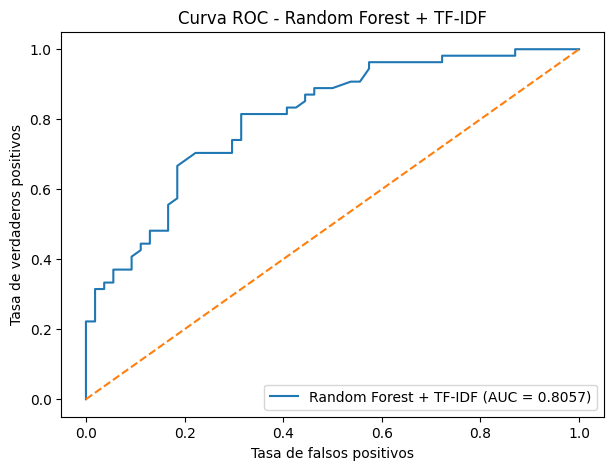

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba_fake)
auc_roc = roc_auc_score(y_test, y_test_proba_fake)

print("AUC ROC:", round(auc_roc, 4))

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest + TF-IDF (AUC = {auc_roc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Random Forest + TF-IDF")
plt.legend()
plt.show()

##Paso 11: tabla comparativa con los papers.

In [ ]:
comparacion_resultados = pd.DataFrame({
    "Referencia": [
        "Modelo propio",
        "Martínez-Gallego et al. (2021)",
        "Llaberia (2025)"
    ],
    "Modelo": [
        "Random Forest + TF-IDF",
        "Random Forest + TF-IDF",
        "BETO + Fine-tuning secuencial"
    ],
    "Accuracy": [
        accuracy_final,
        0.8020,
        0.8205
    ],
    "Precision": [
        precision_fake_final,
        None,
        0.7835
    ],
    "Recall": [
        recall_fake_final,
        None,
        0.8702
    ],
    "F1-score": [
        f1_fake_final,
        None,
        0.8246
    ]
})

comparacion_resultados[["Accuracy", "Precision", "Recall", "F1-score"]] = comparacion_resultados[["Accuracy", "Precision", "Recall", "F1-score"]].round(4)

display(comparacion_resultados)

,Referencia,Modelo,Accuracy,Precision,Recall,F1-score
0,Modelo propio,Random Forest + TF-IDF,0.6481,0.8333,0.3704,0.5128
1,Martínez-Gallego et al. (2021),Random Forest + TF-IDF,0.8020,NaN,NaN,NaN
2,Llaberia (2025),BETO + Fine-tuning secuencial,0.8205,0.7835,0.8702,0.8246


## Paso 12: explicabilidad inicial del modelo

In [ ]:
tfidf = modelo_rf_tfidf.named_steps["tfidf"]
rf = modelo_rf_tfidf.named_steps["rf"]

feature_names = tfidf.get_feature_names_out()
importancias = rf.feature_importances_

df_importancias = pd.DataFrame({
    "feature": feature_names,
    "importancia": importancias
})

df_importancias = df_importancias.sort_values(
    by="importancia",
    ascending=False
).head(30)

display(df_importancias)

,feature,importancia
30025,febrero,0.002218
29564,estudios,0.001815
37134,respuesta,0.001761
5275,centro,0.001669
32798,lunes,0.001566
32966,mantener,0.001500
22701,dosis,0.001452
35177,personas,0.001451
39529,viernes,0.001441
32837,lópez,0.001393


##Paso 13: gráfico de las 20 variables textuales más importantes

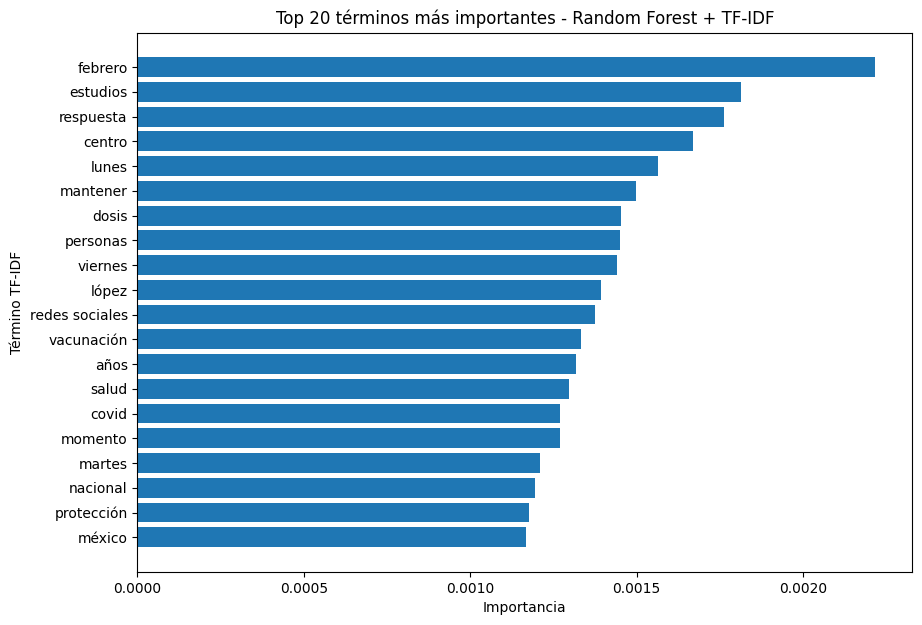

In [ ]:
top_importancias = df_importancias.head(20).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top_importancias["feature"], top_importancias["importancia"])
plt.xlabel("Importancia")
plt.ylabel("Término TF-IDF")
plt.title("Top 20 términos más importantes - Random Forest + TF-IDF")
plt.show()

##Paso 14: análisis de errores del modelo final

In [ ]:
df_resultados_test = df_modeling.loc[X_test_text.index, ["TOPICS", "TEXT", "CATEGORY"]].copy()

df_resultados_test["y_real"] = y_test.values
df_resultados_test["y_pred"] = y_pred_final
df_resultados_test["probabilidad_falsa"] = y_test_proba_fake
df_resultados_test["resultado"] = np.where(
    df_resultados_test["y_real"] == df_resultados_test["y_pred"],
    "Correcto",
    "Error"
)

df_resultados_test["clase_real"] = df_resultados_test["y_real"].map({
    0: "Verdadera",
    1: "Falsa"
})

df_resultados_test["clase_predicha"] = df_resultados_test["y_pred"].map({
    0: "Verdadera",
    1: "Falsa"
})

df_resultados_test["texto_resumen"] = df_resultados_test["TEXT"].str.slice(0, 300)

display(df_resultados_test[[
    "TOPICS",
    "clase_real",
    "clase_predicha",
    "probabilidad_falsa",
    "resultado",
    "texto_resumen"
]].head(10))

display(df_resultados_test["resultado"].value_counts())

,TOPICS,clase_real,clase_predicha,probabilidad_falsa,resultado,texto_resumen
505,Sociedad,Verdadera,Verdadera,0.560,Correcto,El epitafio “Descanse en paz” puede estar en e...
238,Covid-19,Falsa,Verdadera,0.586,Error,COPIADO POR AHI... Una pequeña explicación.ya ...
509,Sociedad,Falsa,Verdadera,0.654,Error,El director del Centro de Coordinación de Aler...
61,Covid-19,Falsa,Falsa,0.776,Correcto,México fue el primero en activar medidas contr...
122,Covid-19,Falsa,Verdadera,0.642,Error,Vacuna COVID = DAÑO GENÉTICO IRREVERSIBLE - UN...
237,Covid-19,Falsa,Verdadera,0.608,Error,"Xalapa, Ver.- Trascendió desde Palacio de Gobi..."
394,Política,Falsa,Falsa,0.912,Correcto,Denuncia Pública Se veía venir... En Gualaceo ...
388,Covid-19,Falsa,Verdadera,0.492,Error,"La empresa mexicana Truekx de México, dedicada..."
508,Sociedad,Verdadera,Verdadera,0.354,Correcto,La exsecretaria de la Convención Marco de Camb...
357,Covid-19,Falsa,Verdadera,0.680,Error,"?????EL AVISO IMPORTANTE Hola, soy Laila Ahmad..."


,count
resultado,
Correcto,70
Error,38


## Paso 15: analizar los errores por tipo y por topic

In [ ]:
tabla_error_tipo = pd.crosstab(
    df_resultados_test["clase_real"],
    df_resultados_test["clase_predicha"],
    margins=True,
    margins_name="Total"
)

display(tabla_error_tipo)

errores_por_topic = (
    df_resultados_test
    .groupby(["TOPICS", "resultado"])
    .size()
    .reset_index(name="cantidad")
)

display(errores_por_topic)

errores_solo = df_resultados_test[df_resultados_test["resultado"] == "Error"].copy()

errores_detalle = (
    errores_solo
    .groupby(["TOPICS", "clase_real", "clase_predicha"])
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

display(errores_detalle)

clase_predicha,Falsa,Verdadera,Total
clase_real,,,
Falsa,20,34,54
Verdadera,4,50,54
Total,24,84,108


,TOPICS,resultado,cantidad
0,Covid-19,Correcto,32
1,Covid-19,Error,20
2,Política,Correcto,14
3,Política,Error,7
4,Sociedad,Correcto,24
5,Sociedad,Error,11


,TOPICS,clase_real,clase_predicha,cantidad
0,Covid-19,Falsa,Verdadera,20
3,Sociedad,Falsa,Verdadera,9
1,Política,Falsa,Verdadera,5
2,Política,Verdadera,Falsa,2
4,Sociedad,Verdadera,Falsa,2


##Paso 16: gráfico de errores por topic

resultado,Correcto,Error
TOPICS,,
Covid-19,32,20
Política,14,7
Sociedad,24,11


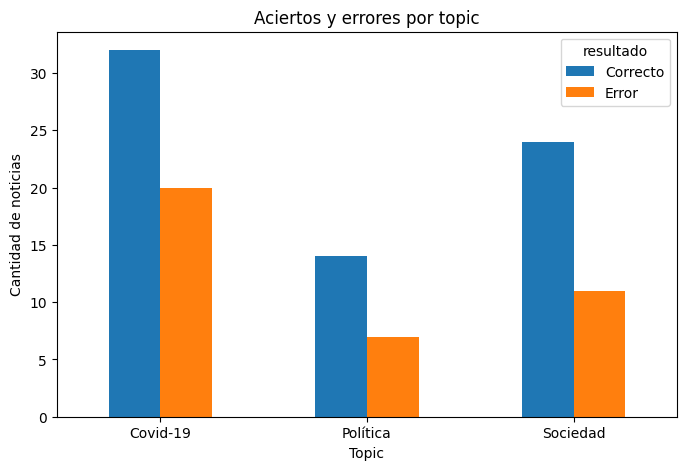

In [ ]:
tabla_topic_resultado = pd.crosstab(
    df_resultados_test["TOPICS"],
    df_resultados_test["resultado"]
)

display(tabla_topic_resultado)

tabla_topic_resultado.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Aciertos y errores por topic")
plt.xlabel("Topic")
plt.ylabel("Cantidad de noticias")
plt.xticks(rotation=0)
plt.show()

## Paso 16: revisar ejemplos de errores críticos

In [ ]:
falsos_negativos = df_resultados_test[
    (df_resultados_test["clase_real"] == "Falsa") &
    (df_resultados_test["clase_predicha"] == "Verdadera")
].copy()

falsos_positivos = df_resultados_test[
    (df_resultados_test["clase_real"] == "Verdadera") &
    (df_resultados_test["clase_predicha"] == "Falsa")
].copy()

falsos_negativos = falsos_negativos.sort_values("probabilidad_falsa", ascending=False)
falsos_positivos = falsos_positivos.sort_values("probabilidad_falsa", ascending=False)

print("Cantidad de falsos negativos:")
print(len(falsos_negativos))

display(falsos_negativos[[
    "TOPICS",
    "clase_real",
    "clase_predicha",
    "probabilidad_falsa",
    "texto_resumen"
]].head(10))

print("Cantidad de falsos positivos:")
print(len(falsos_positivos))

display(falsos_positivos[[
    "TOPICS",
    "clase_real",
    "clase_predicha",
    "probabilidad_falsa",
    "texto_resumen"
]].head(10))

Cantidad de falsos negativos:
34


,TOPICS,clase_real,clase_predicha,probabilidad_falsa,texto_resumen
227,Covid-19,Falsa,Verdadera,0.682,La reinhalación del aire que respiramos conduc...
357,Covid-19,Falsa,Verdadera,0.680,"?????EL AVISO IMPORTANTE Hola, soy Laila Ahmad..."
469,Sociedad,Falsa,Verdadera,0.678,Ya hemos visto de todo. Las redes sociales y e...
467,Política,Falsa,Verdadera,0.674,"""Empiezo por una cosa que inevitablemente he e..."
79,Covid-19,Falsa,Verdadera,0.670,ATENCIÓN ESTO NO ES UN JUEGO!!!la vacunaa es l...
344,Sociedad,Falsa,Verdadera,0.662,"La youtuber Jenny McDermott, conocida por tene..."
19,Política,Falsa,Verdadera,0.654,"El presidente de Rusia,Vladimir Putín, destroz..."
509,Sociedad,Falsa,Verdadera,0.654,El director del Centro de Coordinación de Aler...
101,Sociedad,Falsa,Verdadera,0.650,Las presuntas irregularidades en las cuentas d...
314,Sociedad,Falsa,Verdadera,0.648,“Los empresarios de los chiringuitos malagueño...


Cantidad de falsos positivos:
4


,TOPICS,clase_real,clase_predicha,probabilidad_falsa,texto_resumen
328,Política,Verdadera,Falsa,0.768,La líder de Anticapitalistas y expresidenta de...
165,Sociedad,Verdadera,Falsa,0.718,Amplían período de reclutamiento para servicio...
245,Política,Verdadera,Falsa,0.710,El presidente Movimiento Regeneración Nacional...
462,Sociedad,Verdadera,Falsa,0.702,"El alcalde de Alcoi (Alicante), Toni Francés, ..."


## Paso 17: crear variables estilométricas

In [ ]:
df_modeling_style = df_modeling.copy()

df_modeling_style["num_caracteres"] = df_modeling_style["TEXT"].astype(str).str.len()
df_modeling_style["num_palabras"] = df_modeling_style["TEXT"].astype(str).str.split().str.len()
df_modeling_style["num_exclamaciones"] = df_modeling_style["TEXT"].astype(str).str.count("!")
df_modeling_style["num_interrogaciones"] = df_modeling_style["TEXT"].astype(str).str.count(r"\?")
df_modeling_style["num_mayusculas"] = df_modeling_style["TEXT"].astype(str).apply(lambda x: sum(1 for c in x if c.isupper()))
df_modeling_style["num_digitos"] = df_modeling_style["TEXT"].astype(str).apply(lambda x: sum(1 for c in x if c.isdigit()))
df_modeling_style["num_urls"] = df_modeling_style["TEXT"].astype(str).apply(lambda x: len(re.findall(r"http\S+|www\S+", x)))
df_modeling_style["prop_mayusculas"] = df_modeling_style["num_mayusculas"] / df_modeling_style["num_caracteres"]

columnas_estilo = [
    "num_caracteres",
    "num_palabras",
    "num_exclamaciones",
    "num_interrogaciones",
    "num_mayusculas",
    "num_digitos",
    "num_urls",
    "prop_mayusculas"
]

display(df_modeling_style[columnas_estilo].describe().round(4))

display(df_modeling_style[["CATEGORY", "TOPICS"] + columnas_estilo].head())

,num_caracteres,num_palabras,num_exclamaciones,num_interrogaciones,num_mayusculas,num_digitos,num_urls,prop_mayusculas
count,539.0000,539.0000,539.0000,539.0000,539.0000,539.0000,539.0000,539.0000
mean,3181.3952,522.2245,0.3822,1.0891,81.1985,23.1874,0.0167,0.0308
std,2691.7860,441.6853,1.8175,4.0231,85.5759,29.7903,0.2061,0.0552
min,261.0000,47.0000,0.0000,0.0000,5.0000,0.0000,0.0000,0.0055
25%,1512.0000,250.0000,0.0000,0.0000,33.0000,5.0000,0.0000,0.0174
50%,2426.0000,401.0000,0.0000,0.0000,57.0000,14.0000,0.0000,0.0225
75%,3995.5000,655.5000,0.0000,1.0000,97.5000,31.0000,0.0000,0.0300
max,25663.0000,4006.0000,26.0000,53.0000,902.0000,345.0000,4.0000,0.7730


,CATEGORY,TOPICS,num_caracteres,num_palabras,num_exclamaciones,num_interrogaciones,num_mayusculas,num_digitos,num_urls,prop_mayusculas
0,True,Covid-19,4568,786,0,0,61,20,0,0.013354
1,False,Política,1803,288,0,0,50,0,0,0.027732
2,True,Política,4118,658,0,0,64,32,0,0.015542
3,False,Política,1232,209,0,0,21,6,0,0.017045
4,True,Sociedad,1717,280,0,0,29,23,0,0.016890


## Paso 18: entrenar Random Forest + TF-IDF + variables estilométricas

In [ ]:
X_style = df_modeling_style[["TEXT"] + columnas_estilo].copy()
y_style = df_modeling_style["y"]

X_train_style = X_style.loc[X_train_text.index]
X_test_style = X_style.loc[X_test_text.index]

preprocesador_style = ColumnTransformer([
    ("tfidf", TfidfVectorizer(
        stop_words=stopwords_es,
        lowercase=True,
        max_features=40000,
        ngram_range=(1, 2),
        token_pattern=r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]{3,}\b"
    ), "TEXT"),
    ("style", "passthrough", columnas_estilo)
])

modelo_rf_tfidf_style = Pipeline([
    ("features", preprocesador_style),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_features=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

modelo_rf_tfidf_style.fit(X_train_style, y_train)

y_pred_style_050 = modelo_rf_tfidf_style.predict(X_test_style)
y_proba_style_fake = modelo_rf_tfidf_style.predict_proba(X_test_style)[:, 1]

metricas_style_050 = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision clase falsa", "Recall clase falsa", "F1-score clase falsa", "AUC ROC"],
    "Valor": [
        accuracy_score(y_test, y_pred_style_050),
        precision_score(y_test, y_pred_style_050, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_style_050, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_style_050, pos_label=1, zero_division=0),
        roc_auc_score(y_test, y_proba_style_fake)
    ]
})

metricas_style_050["Valor"] = metricas_style_050["Valor"].round(4)

display(metricas_style_050)

print(classification_report(
    y_test,
    y_pred_style_050,
    target_names=["Verdadera", "Falsa"],
    zero_division=0
))

matriz_confusion_style_050 = confusion_matrix(y_test, y_pred_style_050)

display(pd.DataFrame(
    matriz_confusion_style_050,
    index=["Real verdadera", "Real falsa"],
    columns=["Predicha verdadera", "Predicha falsa"]
))

,Métrica,Valor
0,Accuracy,0.6667
1,Precision clase falsa,0.6154
2,Recall clase falsa,0.8889
3,F1-score clase falsa,0.7273
4,AUC ROC,0.8001


              precision    recall  f1-score   support

   Verdadera       0.80      0.44      0.57        54
       Falsa       0.62      0.89      0.73        54

    accuracy                           0.67       108
   macro avg       0.71      0.67      0.65       108
weighted avg       0.71      0.67      0.65       108



,Predicha verdadera,Predicha falsa
Real verdadera,24,30
Real falsa,6,48


In [ ]:
resultados_modelos = pd.DataFrame({
    "Experimento": [
        "RF + TF-IDF | umbral 0.50",
        "RF + TF-IDF | umbral 0.70",
        "RF + TF-IDF + estilo | umbral 0.50"
    ],
    "Accuracy": [
        accuracy,
        accuracy_final,
        accuracy_score(y_test, y_pred_style_050)
    ],
    "Precision clase falsa": [
        precision_fake,
        precision_fake_final,
        precision_score(y_test, y_pred_style_050, pos_label=1, zero_division=0)
    ],
    "Recall clase falsa": [
        recall_fake,
        recall_fake_final,
        recall_score(y_test, y_pred_style_050, pos_label=1, zero_division=0)
    ],
    "F1-score clase falsa": [
        f1_fake,
        f1_fake_final,
        f1_score(y_test, y_pred_style_050, pos_label=1, zero_division=0)
    ],
    "AUC ROC": [
        auc_roc,
        auc_roc,
        roc_auc_score(y_test, y_proba_style_fake)
    ]
})

resultados_modelos = resultados_modelos.round(4)

display(resultados_modelos)

,Experimento,Accuracy,Precision clase falsa,Recall clase falsa,F1-score clase falsa,AUC ROC
0,RF + TF-IDF | umbral 0.50,0.6852,0.6282,0.9074,0.7424,0.8057
1,RF + TF-IDF | umbral 0.70,0.6481,0.8333,0.3704,0.5128,0.8057
2,RF + TF-IDF + estilo | umbral 0.50,0.6667,0.6154,0.8889,0.7273,0.8001


##Paso 19: Random Forest + TF-IDF con stemming

In [ ]:
stemmer_es = SnowballStemmer("spanish")
stopwords_set = set(stopwords_es)

def tokenizador_stemming(texto):
    texto = str(texto).lower()
    tokens = re.findall(r"\b[a-záéíóúñü]{3,}\b", texto)
    tokens = [t for t in tokens if t not in stopwords_set]
    tokens = [stemmer_es.stem(t) for t in tokens]
    return tokens

modelo_rf_tfidf_stem = Pipeline([
    ("tfidf", TfidfVectorizer(
        tokenizer=tokenizador_stemming,
        token_pattern=None,
        max_features=40000,
        ngram_range=(1, 2)
    )),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_features=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

modelo_rf_tfidf_stem.fit(X_train_text, y_train)

y_pred_stem_050 = modelo_rf_tfidf_stem.predict(X_test_text)
y_proba_stem_fake = modelo_rf_tfidf_stem.predict_proba(X_test_text)[:, 1]

metricas_stem_050 = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision clase falsa", "Recall clase falsa", "F1-score clase falsa", "AUC ROC"],
    "Valor": [
        accuracy_score(y_test, y_pred_stem_050),
        precision_score(y_test, y_pred_stem_050, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_stem_050, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_stem_050, pos_label=1, zero_division=0),
        roc_auc_score(y_test, y_proba_stem_fake)
    ]
})

metricas_stem_050["Valor"] = metricas_stem_050["Valor"].round(4)

display(metricas_stem_050)

print(classification_report(
    y_test,
    y_pred_stem_050,
    target_names=["Verdadera", "Falsa"],
    zero_division=0
))

matriz_confusion_stem_050 = confusion_matrix(y_test, y_pred_stem_050)

display(pd.DataFrame(
    matriz_confusion_stem_050,
    index=["Real verdadera", "Real falsa"],
    columns=["Predicha verdadera", "Predicha falsa"]
))

,Métrica,Valor
0,Accuracy,0.6574
1,Precision clase falsa,0.6049
2,Recall clase falsa,0.9074
3,F1-score clase falsa,0.7259
4,AUC ROC,0.7985


              precision    recall  f1-score   support

   Verdadera       0.81      0.41      0.54        54
       Falsa       0.60      0.91      0.73        54

    accuracy                           0.66       108
   macro avg       0.71      0.66      0.63       108
weighted avg       0.71      0.66      0.63       108



,Predicha verdadera,Predicha falsa
Real verdadera,22,32
Real falsa,5,49


In [ ]:
nuevo_resultado = pd.DataFrame({
    "Experimento": [
        "RF + TF-IDF + stemming | umbral 0.50"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_stem_050)
    ],
    "Precision clase falsa": [
        precision_score(y_test, y_pred_stem_050, pos_label=1, zero_division=0)
    ],
    "Recall clase falsa": [
        recall_score(y_test, y_pred_stem_050, pos_label=1, zero_division=0)
    ],
    "F1-score clase falsa": [
        f1_score(y_test, y_pred_stem_050, pos_label=1, zero_division=0)
    ],
    "AUC ROC": [
        roc_auc_score(y_test, y_proba_stem_fake)
    ]
})

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)

resultados_modelos = resultados_modelos.round(4)

display(resultados_modelos)

,Experimento,Accuracy,Precision clase falsa,Recall clase falsa,F1-score clase falsa,AUC ROC
0,RF + TF-IDF | umbral 0.50,0.6852,0.6282,0.9074,0.7424,0.8057
1,RF + TF-IDF | umbral 0.70,0.6481,0.8333,0.3704,0.5128,0.8057
2,RF + TF-IDF + estilo | umbral 0.50,0.6667,0.6154,0.8889,0.7273,0.8001
3,RF + TF-IDF + stemming | umbral 0.50,0.6574,0.6049,0.9074,0.7259,0.7985


##Paso 21: RF + TF-IDF optimizado

In [ ]:
modelo_rf_tfidf_opt = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words=stopwords_es,
        lowercase=True,
        max_features=20000,
        min_df=2,
        max_df=0.90,
        ngram_range=(1, 2),
        sublinear_tf=True,
        token_pattern=r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]{3,}\b"
    )),
    ("rf", RandomForestClassifier(
        n_estimators=700,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

modelo_rf_tfidf_opt.fit(X_train_text, y_train)

y_pred_opt_050 = modelo_rf_tfidf_opt.predict(X_test_text)
y_proba_opt_fake = modelo_rf_tfidf_opt.predict_proba(X_test_text)[:, 1]

metricas_opt_050 = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision clase falsa", "Recall clase falsa", "F1-score clase falsa", "AUC ROC"],
    "Valor": [
        accuracy_score(y_test, y_pred_opt_050),
        precision_score(y_test, y_pred_opt_050, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_opt_050, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_opt_050, pos_label=1, zero_division=0),
        roc_auc_score(y_test, y_proba_opt_fake)
    ]
})

metricas_opt_050["Valor"] = metricas_opt_050["Valor"].round(4)

display(metricas_opt_050)

print(classification_report(
    y_test,
    y_pred_opt_050,
    target_names=["Verdadera", "Falsa"],
    zero_division=0
))

matriz_confusion_opt_050 = confusion_matrix(y_test, y_pred_opt_050)

display(pd.DataFrame(
    matriz_confusion_opt_050,
    index=["Real verdadera", "Real falsa"],
    columns=["Predicha verdadera", "Predicha falsa"]
))

,Métrica,Valor
0,Accuracy,0.7407
1,Precision clase falsa,0.7097
2,Recall clase falsa,0.8148
3,F1-score clase falsa,0.7586
4,AUC ROC,0.8169


              precision    recall  f1-score   support

   Verdadera       0.78      0.67      0.72        54
       Falsa       0.71      0.81      0.76        54

    accuracy                           0.74       108
   macro avg       0.75      0.74      0.74       108
weighted avg       0.75      0.74      0.74       108



,Predicha verdadera,Predicha falsa
Real verdadera,36,18
Real falsa,10,44


In [ ]:
nuevo_resultado = pd.DataFrame({
    "Experimento": [
        "RF + TF-IDF optimizado | umbral 0.50"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_opt_050)
    ],
    "Precision clase falsa": [
        precision_score(y_test, y_pred_opt_050, pos_label=1, zero_division=0)
    ],
    "Recall clase falsa": [
        recall_score(y_test, y_pred_opt_050, pos_label=1, zero_division=0)
    ],
    "F1-score clase falsa": [
        f1_score(y_test, y_pred_opt_050, pos_label=1, zero_division=0)
    ],
    "AUC ROC": [
        roc_auc_score(y_test, y_proba_opt_fake)
    ]
})

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)

resultados_modelos = resultados_modelos.round(4)

display(resultados_modelos)

,Experimento,Accuracy,Precision clase falsa,Recall clase falsa,F1-score clase falsa,AUC ROC
0,RF + TF-IDF | umbral 0.50,0.6852,0.6282,0.9074,0.7424,0.8057
1,RF + TF-IDF | umbral 0.70,0.6481,0.8333,0.3704,0.5128,0.8057
2,RF + TF-IDF + estilo | umbral 0.50,0.6667,0.6154,0.8889,0.7273,0.8001
3,RF + TF-IDF + stemming | umbral 0.50,0.6574,0.6049,0.9074,0.7259,0.7985
4,RF + TF-IDF optimizado | umbral 0.50,0.7407,0.7097,0.8148,0.7586,0.8169


## Paso 23: umbrales del modelo optimizado

In [ ]:
modelo_opt_validacion = clone(modelo_rf_tfidf_opt)

modelo_opt_validacion.fit(X_train_final_text, y_train_final)

y_val_proba_opt_fake = modelo_opt_validacion.predict_proba(X_val_text)[:, 1]

umbrales = np.arange(0.30, 0.91, 0.05)

resultados_umbral_opt = []

for umbral in umbrales:
    y_val_pred_opt_umbral = (y_val_proba_opt_fake >= umbral).astype(int)

    resultados_umbral_opt.append({
        "umbral": round(umbral, 2),
        "accuracy": round(accuracy_score(y_val, y_val_pred_opt_umbral), 4),
        "precision_fake": round(precision_score(y_val, y_val_pred_opt_umbral, pos_label=1, zero_division=0), 4),
        "recall_fake": round(recall_score(y_val, y_val_pred_opt_umbral, pos_label=1, zero_division=0), 4),
        "f1_fake": round(f1_score(y_val, y_val_pred_opt_umbral, pos_label=1, zero_division=0), 4)
    })

df_umbrales_opt = pd.DataFrame(resultados_umbral_opt)

display(df_umbrales_opt)

,umbral,accuracy,precision_fake,recall_fake,f1_fake
0,0.30,0.5402,0.5181,1.0000,0.6825
1,0.35,0.5402,0.5181,1.0000,0.6825
2,0.40,0.5632,0.5316,0.9767,0.6885
3,0.45,0.5747,0.5455,0.8372,0.6606
4,0.50,0.6092,0.5918,0.6744,0.6304
5,0.55,0.6092,0.6154,0.5581,0.5854
6,0.60,0.6322,0.7200,0.4186,0.5294
7,0.65,0.6322,0.8667,0.3023,0.4483
8,0.70,0.5977,0.9000,0.2093,0.3396
9,0.75,0.6092,1.0000,0.2093,0.3462


## Paso 24: RF + TF-IDF optimizado + estilo

In [ ]:
X_opt_style = df_modeling_style[["TEXT"] + columnas_estilo].copy()

X_train_opt_style = X_opt_style.loc[X_train_text.index]
X_test_opt_style = X_opt_style.loc[X_test_text.index]

preprocesador_opt_style = ColumnTransformer([
    ("tfidf", TfidfVectorizer(
        stop_words=stopwords_es,
        lowercase=True,
        max_features=20000,
        min_df=2,
        max_df=0.90,
        ngram_range=(1, 2),
        sublinear_tf=True,
        token_pattern=r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑüÜ]{3,}\b"
    ), "TEXT"),
    ("style", StandardScaler(with_mean=False), columnas_estilo)
])

modelo_rf_tfidf_opt_style = Pipeline([
    ("features", preprocesador_opt_style),
    ("rf", RandomForestClassifier(
        n_estimators=700,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

modelo_rf_tfidf_opt_style.fit(X_train_opt_style, y_train)

y_pred_opt_style_050 = modelo_rf_tfidf_opt_style.predict(X_test_opt_style)
y_proba_opt_style_fake = modelo_rf_tfidf_opt_style.predict_proba(X_test_opt_style)[:, 1]

metricas_opt_style_050 = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision clase falsa", "Recall clase falsa", "F1-score clase falsa", "AUC ROC"],
    "Valor": [
        accuracy_score(y_test, y_pred_opt_style_050),
        precision_score(y_test, y_pred_opt_style_050, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_opt_style_050, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_opt_style_050, pos_label=1, zero_division=0),
        roc_auc_score(y_test, y_proba_opt_style_fake)
    ]
})

metricas_opt_style_050["Valor"] = metricas_opt_style_050["Valor"].round(4)

display(metricas_opt_style_050)

print(classification_report(
    y_test,
    y_pred_opt_style_050,
    target_names=["Verdadera", "Falsa"],
    zero_division=0
))

matriz_confusion_opt_style_050 = confusion_matrix(y_test, y_pred_opt_style_050)

display(pd.DataFrame(
    matriz_confusion_opt_style_050,
    index=["Real verdadera", "Real falsa"],
    columns=["Predicha verdadera", "Predicha falsa"]
))

,Métrica,Valor
0,Accuracy,0.7593
1,Precision clase falsa,0.7333
2,Recall clase falsa,0.8148
3,F1-score clase falsa,0.7719
4,AUC ROC,0.8234


              precision    recall  f1-score   support

   Verdadera       0.79      0.70      0.75        54
       Falsa       0.73      0.81      0.77        54

    accuracy                           0.76       108
   macro avg       0.76      0.76      0.76       108
weighted avg       0.76      0.76      0.76       108



,Predicha verdadera,Predicha falsa
Real verdadera,38,16
Real falsa,10,44


##Paso 25: guardar modelo optimizado + estilo

In [ ]:
nuevo_resultado = pd.DataFrame({
    "Experimento": [
        "RF + TF-IDF optimizado + estilo | umbral 0.50"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_opt_style_050)
    ],
    "Precision clase falsa": [
        precision_score(y_test, y_pred_opt_style_050, pos_label=1, zero_division=0)
    ],
    "Recall clase falsa": [
        recall_score(y_test, y_pred_opt_style_050, pos_label=1, zero_division=0)
    ],
    "F1-score clase falsa": [
        f1_score(y_test, y_pred_opt_style_050, pos_label=1, zero_division=0)
    ],
    "AUC ROC": [
        roc_auc_score(y_test, y_proba_opt_style_fake)
    ]
})

resultados_modelos = pd.concat(
    [resultados_modelos, nuevo_resultado],
    ignore_index=True
)

resultados_modelos = resultados_modelos.round(4)

display(resultados_modelos)

,Experimento,Accuracy,Precision clase falsa,Recall clase falsa,F1-score clase falsa,AUC ROC
0,RF + TF-IDF | umbral 0.50,0.6852,0.6282,0.9074,0.7424,0.8057
1,RF + TF-IDF | umbral 0.70,0.6481,0.8333,0.3704,0.5128,0.8057
2,RF + TF-IDF + estilo | umbral 0.50,0.6667,0.6154,0.8889,0.7273,0.8001
3,RF + TF-IDF + stemming | umbral 0.50,0.6574,0.6049,0.9074,0.7259,0.7985
4,RF + TF-IDF optimizado | umbral 0.50,0.7407,0.7097,0.8148,0.7586,0.8169
5,RF + TF-IDF optimizado + estilo | umbral 0.50,0.7593,0.7333,0.8148,0.7719,0.8234


##Paso 26: evaluar umbrales del modelo optimizado + estilo

In [ ]:
X_train_final_opt_style = X_opt_style.loc[X_train_final_text.index]
X_val_opt_style = X_opt_style.loc[X_val_text.index]

modelo_opt_style_validacion = clone(modelo_rf_tfidf_opt_style)

modelo_opt_style_validacion.fit(X_train_final_opt_style, y_train_final)

y_val_proba_opt_style_fake = modelo_opt_style_validacion.predict_proba(X_val_opt_style)[:, 1]

umbrales = np.arange(0.30, 0.91, 0.05)

resultados_umbral_opt_style = []

for umbral in umbrales:
    y_val_pred_opt_style_umbral = (y_val_proba_opt_style_fake >= umbral).astype(int)

    resultados_umbral_opt_style.append({
        "umbral": round(umbral, 2),
        "accuracy": round(accuracy_score(y_val, y_val_pred_opt_style_umbral), 4),
        "precision_fake": round(precision_score(y_val, y_val_pred_opt_style_umbral, pos_label=1, zero_division=0), 4),
        "recall_fake": round(recall_score(y_val, y_val_pred_opt_style_umbral, pos_label=1, zero_division=0), 4),
        "f1_fake": round(f1_score(y_val, y_val_pred_opt_style_umbral, pos_label=1, zero_division=0), 4)
    })

df_umbrales_opt_style = pd.DataFrame(resultados_umbral_opt_style)

display(df_umbrales_opt_style)

,umbral,accuracy,precision_fake,recall_fake,f1_fake
0,0.30,0.5402,0.5181,1.0000,0.6825
1,0.35,0.5632,0.5309,1.0000,0.6935
2,0.40,0.5862,0.5479,0.9302,0.6897
3,0.45,0.5977,0.5645,0.8140,0.6667
4,0.50,0.6207,0.6136,0.6279,0.6207
5,0.55,0.6092,0.6216,0.5349,0.5750
6,0.60,0.6552,0.7097,0.5116,0.5946
7,0.65,0.6782,0.8571,0.4186,0.5625
8,0.70,0.6322,1.0000,0.2558,0.4074
9,0.75,0.6092,1.0000,0.2093,0.3462


##Paso 27: definir modelo final

In [ ]:
modelo_final = modelo_rf_tfidf_opt_style
umbral_final = 0.50

X_test_final = X_test_opt_style

y_proba_final_modelo = y_proba_opt_style_fake
y_pred_final_modelo = (y_proba_final_modelo >= umbral_final).astype(int)

matriz_confusion_final_modelo = confusion_matrix(y_test, y_pred_final_modelo)

metricas_final_modelo = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision clase falsa",
        "Recall clase falsa",
        "F1-score clase falsa",
        "AUC ROC"
    ],
    "Valor": [
        accuracy_score(y_test, y_pred_final_modelo),
        precision_score(y_test, y_pred_final_modelo, pos_label=1, zero_division=0),
        recall_score(y_test, y_pred_final_modelo, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_final_modelo, pos_label=1, zero_division=0),
        roc_auc_score(y_test, y_proba_final_modelo)
    ]
})

metricas_final_modelo["Valor"] = metricas_final_modelo["Valor"].round(4)

display(metricas_final_modelo)

display(pd.DataFrame(
    matriz_confusion_final_modelo,
    index=["Real verdadera", "Real falsa"],
    columns=["Predicha verdadera", "Predicha falsa"]
))

,Métrica,Valor
0,Accuracy,0.7593
1,Precision clase falsa,0.7333
2,Recall clase falsa,0.8148
3,F1-score clase falsa,0.7719
4,AUC ROC,0.8234


,Predicha verdadera,Predicha falsa
Real verdadera,38,16
Real falsa,10,44


##Paso 28: marcar el mejor modelo en la tabla de experimentos

In [ ]:
resultados_modelos["Seleccionado"] = "No"

resultados_modelos.loc[
    resultados_modelos["Experimento"] == "RF + TF-IDF optimizado + estilo | umbral 0.50",
    "Seleccionado"
] = "Sí"

display(resultados_modelos)

,Experimento,Accuracy,Precision clase falsa,Recall clase falsa,F1-score clase falsa,AUC ROC,Seleccionado
0,RF + TF-IDF | umbral 0.50,0.6852,0.6282,0.9074,0.7424,0.8057,No
1,RF + TF-IDF | umbral 0.70,0.6481,0.8333,0.3704,0.5128,0.8057,No
2,RF + TF-IDF + estilo | umbral 0.50,0.6667,0.6154,0.8889,0.7273,0.8001,No
3,RF + TF-IDF + stemming | umbral 0.50,0.6574,0.6049,0.9074,0.7259,0.7985,No
4,RF + TF-IDF optimizado | umbral 0.50,0.7407,0.7097,0.8148,0.7586,0.8169,No
5,RF + TF-IDF optimizado + estilo | umbral 0.50,0.7593,0.7333,0.8148,0.7719,0.8234,Sí


##Paso 29: matriz de confusión final del modelo seleccionado

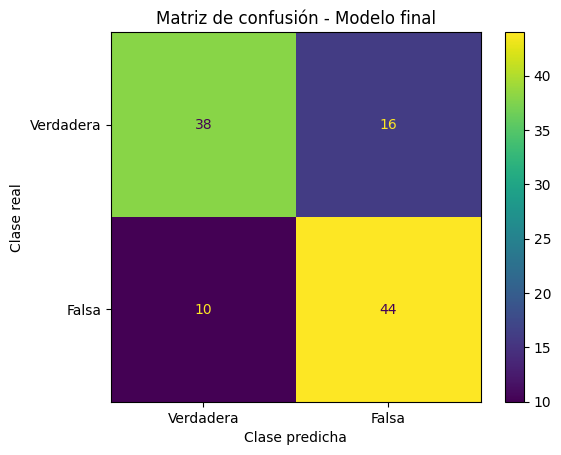

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_final_modelo,
    display_labels=["Verdadera", "Falsa"]
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - Modelo final")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

##Paso 30: curva ROC final del modelo seleccionado|

AUC ROC final: 0.8234


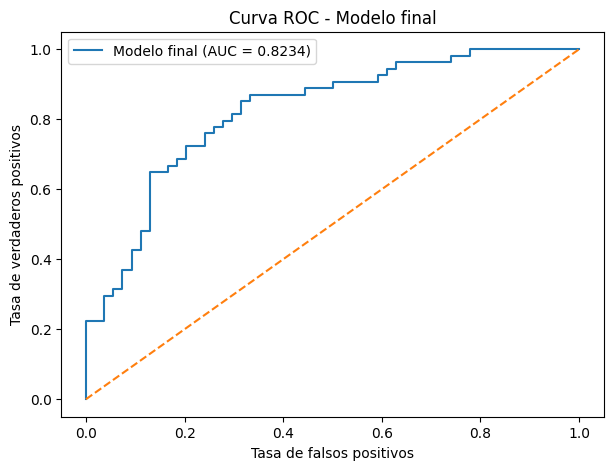

In [ ]:
fpr_final, tpr_final, thresholds_final = roc_curve(y_test, y_proba_final_modelo)
auc_final = roc_auc_score(y_test, y_proba_final_modelo)

print("AUC ROC final:", round(auc_final, 4))

plt.figure(figsize=(7, 5))
plt.plot(fpr_final, tpr_final, label=f"Modelo final (AUC = {auc_final:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Modelo final")
plt.legend()
plt.show()

## Paso 31: comparación final con papers

In [ ]:
comparacion_papers = pd.DataFrame({
    "Experimento": [
        "Martínez-Gallego et al. (2021) | RF + TF-IDF",
        "Llaberia (2025) | BETO + fine-tuning secuencial"
    ],
    "Accuracy": [
        0.8020,
        0.8205
    ],
    "Precision clase falsa": [
        None,
        0.7835
    ],
    "Recall clase falsa": [
        None,
        0.8702
    ],
    "AUC ROC": [
        None,
        None
    ],
    "Tipo": [
        "Paper",
        "Paper"
    ]
})

modelos_propios_comparacion = resultados_modelos[[
    "Experimento",
    "Accuracy",
    "Precision clase falsa",
    "Recall clase falsa",
    "AUC ROC"
]].copy()

modelos_propios_comparacion["Tipo"] = "Modelo propio"

comparacion_final = pd.concat(
    [modelos_propios_comparacion, comparacion_papers],
    ignore_index=True
)

comparacion_final = comparacion_final.round(4)

display(comparacion_final)

/tmp/ipykernel_2117/617779089.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparacion_final = pd.concat(


,Experimento,Accuracy,Precision clase falsa,Recall clase falsa,AUC ROC,Tipo
0,RF + TF-IDF | umbral 0.50,0.6852,0.6282,0.9074,0.8057,Modelo propio
1,RF + TF-IDF | umbral 0.70,0.6481,0.8333,0.3704,0.8057,Modelo propio
2,RF + TF-IDF + estilo | umbral 0.50,0.6667,0.6154,0.8889,0.8001,Modelo propio
3,RF + TF-IDF + stemming | umbral 0.50,0.6574,0.6049,0.9074,0.7985,Modelo propio
4,RF + TF-IDF optimizado | umbral 0.50,0.7407,0.7097,0.8148,0.8169,Modelo propio
5,RF + TF-IDF optimizado + estilo | umbral 0.50,0.7593,0.7333,0.8148,0.8234,Modelo propio
6,Martínez-Gallego et al. (2021) | RF + TF-IDF,0.8020,NaN,NaN,NaN,Paper
7,Llaberia (2025) | BETO + fine-tuning secuencial,0.8205,0.7835,0.8702,NaN,Paper


## Paso 32: ordenar por la métrica principal Accuracy

In [ ]:
ranking_accuracy = comparacion_final.sort_values(
    by="Accuracy",
    ascending=False
)

display(ranking_accuracy)

,Experimento,Accuracy,Precision clase falsa,Recall clase falsa,AUC ROC,Tipo
7,Llaberia (2025) | BETO + fine-tuning secuencial,0.8205,0.7835,0.8702,NaN,Paper
6,Martínez-Gallego et al. (2021) | RF + TF-IDF,0.8020,NaN,NaN,NaN,Paper
5,RF + TF-IDF optimizado + estilo | umbral 0.50,0.7593,0.7333,0.8148,0.8234,Modelo propio
4,RF + TF-IDF optimizado | umbral 0.50,0.7407,0.7097,0.8148,0.8169,Modelo propio
0,RF + TF-IDF | umbral 0.50,0.6852,0.6282,0.9074,0.8057,Modelo propio
2,RF + TF-IDF + estilo | umbral 0.50,0.6667,0.6154,0.8889,0.8001,Modelo propio
3,RF + TF-IDF + stemming | umbral 0.50,0.6574,0.6049,0.9074,0.7985,Modelo propio
1,RF + TF-IDF | umbral 0.70,0.6481,0.8333,0.3704,0.8057,Modelo propio


## Paso 33: gráfico comparativo principal por Accuracy

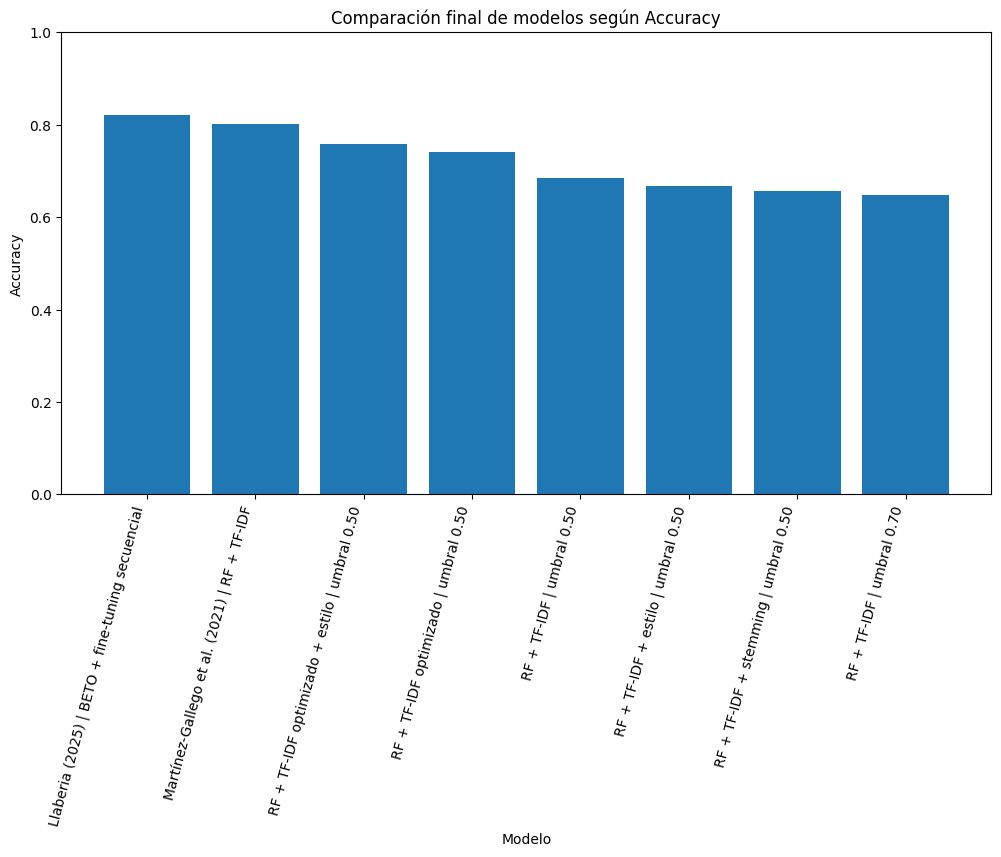

In [ ]:
ranking_accuracy_grafico = ranking_accuracy.copy()

plt.figure(figsize=(12, 6))
plt.bar(
    ranking_accuracy_grafico["Experimento"],
    ranking_accuracy_grafico["Accuracy"]
)

plt.title("Comparación final de modelos según Accuracy")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=75, ha="right")
plt.ylim(0, 1)
plt.show()

## Paso 34: gráfico complementario solo de modelos propios

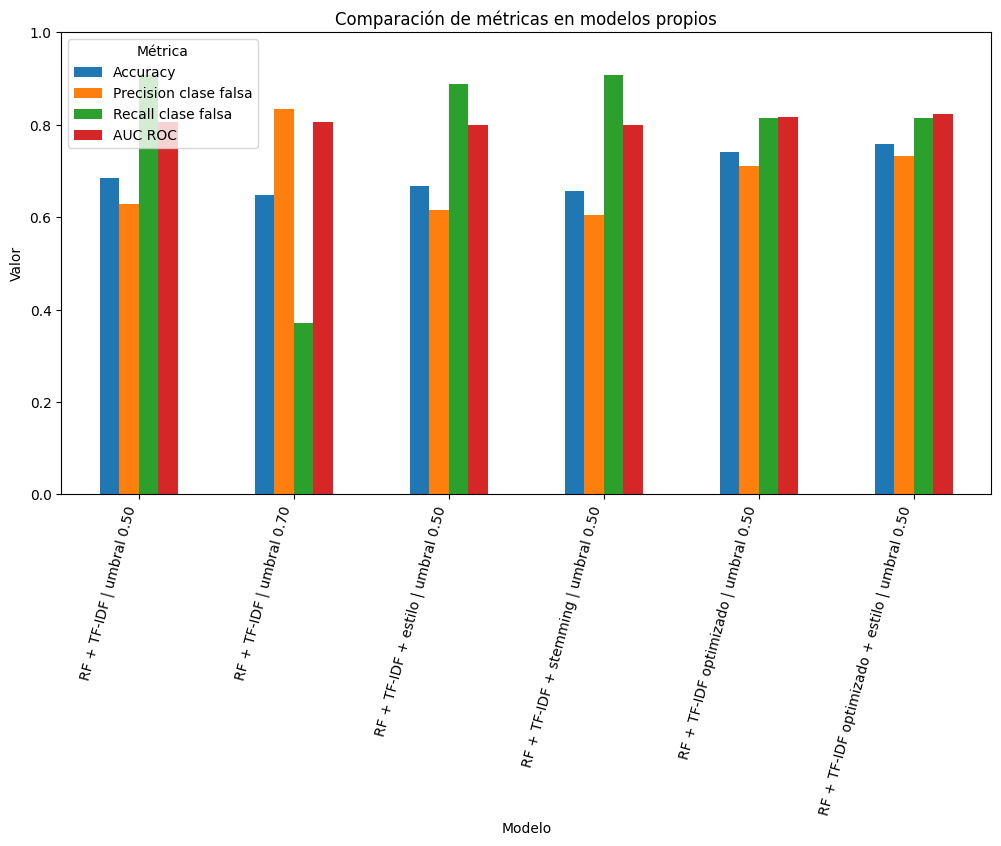

In [ ]:
metricas_grafico = [
    "Accuracy",
    "Precision clase falsa",
    "Recall clase falsa",
    "AUC ROC"
]

modelos_propios_metricas = resultados_modelos.set_index("Experimento")[metricas_grafico]

modelos_propios_metricas.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparación de métricas en modelos propios")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=75, ha="right")
plt.ylim(0, 1)
plt.legend(title="Métrica")
plt.show()